<div style="background: linear-gradient(135deg, #0f0c29, #302b63, #24243e); padding: 40px 30px; border-radius: 16px; text-align: center; margin-bottom: 10px;">
  <h1 style="color: #e0e0ff; font-family: 'Segoe UI', sans-serif; font-size: 2.2em; margin: 0 0 8px 0; letter-spacing: 1px;">🔥 Calorie Burn Efficiency</h1>
  <h3 style="color: #a0a8e8; font-family: 'Segoe UI', sans-serif; font-weight: 300; margin: 0;">Exploração Completa do Dataset · Pandas + Python</h3>
  <p style="color: #6b74c4; margin: 16px 0 0 0; font-size: 0.9em;">Carregamento · Inspeção · Filtros · Tratamento de Nulos · Feature Engineering</p>
  <p style="color: #555a9e; margin: 6px 0 0 0; font-size: 0.8em;">Dataset: 1.000.000 linhas × 15 colunas</p>
</div>

---
## 📦 0. Configuração do Ambiente

Instalação e importação de todas as bibliotecas necessárias.

In [1]:
# ── Instalações ──────────────────────────────────────
# !pip install pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.labelcolor':  '#e0e0ff',
    'xtick.color':      '#a0a8e8',
    'ytick.color':      '#a0a8e8',
    'text.color':       '#e0e0ff',
    'axes.titlecolor':  '#ffffff',
    'grid.color':       '#2a2a5a',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

LABEL_COL = 'calorie_efficiency'   # coluna alvo real do dataset
LABELS    = ['Low Efficiency', 'Moderate', 'High Efficiency']
COLORS    = {
    'High Efficiency': '#7ee8a2',
    'Moderate':        '#f9ca24',
    'Low Efficiency':  '#f0932b',
    'accent':          '#a29bfe',
    'danger':          '#ff6b6b',
}

print('✅ Ambiente configurado!')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

✅ Ambiente configurado!
   pandas 3.0.2 | numpy 2.4.4


---
## 📂 1. Carregamento do Dataset

> **No Google Colab**, é possível carregar o arquivo de duas formas:  
> 1. Upload manual pelo painel lateral de arquivos  
> 2. Montar o Google Drive com `drive.mount('/content/drive')`

O dataset possui **1.000.000 linhas** e **15 colunas** — métricas de atividade, composição corporal, sono, hidratação e a coluna alvo `calorie_efficiency`.

In [2]:
from pathlib import Path

CSV_NAME = "calorie_efficiency_dataset.csv"

# 1) tenta mesmo diretório do notebook
if Path(CSV_NAME).exists():
    df = pd.read_csv(CSV_NAME)
    source = "arquivo local"

# 2) fallback para Colab upload
else:
    try:
        from google.colab import files
        uploaded = files.upload()
        df = pd.read_csv(list(uploaded.keys())[0])
        source = "upload manual (Colab)"
    except Exception:
        raise FileNotFoundError(
            f"Não encontrei {CSV_NAME}. "
            "Coloque o CSV no mesmo diretório do notebook "
            "ou faça upload manual."
        )

print(f"✅ Dataset carregado via: {source}")
print(f"   Linhas : {df.shape[0]:,}")
print(f"   Colunas: {df.shape[1]}")
print(f"   Memória: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

✅ Dataset carregado via: arquivo local
   Linhas : 1,000,000
   Colunas: 15
   Memória: 174.8 MB


---
## 🔍 2. Inspeção Inicial

### 2.1 — `head()` · Primeiras linhas

In [3]:
df.head(8)

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency
5,53,8517,94,1500,6.42,3.76,25.28,3,0.391,0.302,59.2,96.0,2,0.754,Low Efficiency
6,23,8263,48,1500,5.11,2.67,17.28,2,0.422,0.128,66.7,117.5,1,0.492,Low Efficiency
7,29,6901,83,1500,6.11,1.14,22.74,7,0.468,0.277,66.6,111.7,1,0.426,Low Efficiency


### 2.2 — `info()` · Tipos e memória

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   steps_per_day             1000000 non-null  int64  
 2   active_minutes            1000000 non-null  int64  
 3   calories_burned           1000000 non-null  int64  
 4   sleep_hours               1000000 non-null  float64
 5   hydration_liters          1000000 non-null  float64
 6   bmi                       1000000 non-null  float64
 7   workouts_per_week         1000000 non-null  int64  
 8   muscle_mass_ratio         1000000 non-null  float64
 9   body_fat_percentage       1000000 non-null  float64
 10  heart_rate_resting        1000000 non-null  float64
 11  heart_rate_avg            1000000 non-null  float64
 12  continuous_exercise_days  1000000 non-null  int64  
 13  efficiency_score          1000000 non-n

### 2.3 — `describe()` · Estatísticas descritivas

In [5]:
df.describe().round(2)

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score
count,1000000.00,1000000.00,1000000.00,1000000.0,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,40.98,7001.23,69.67,1500.0,6.50,2.50,24.22,2.98,0.35,0.25,66.00,106.04,2.43,0.88
std,13.55,2482.81,28.60,0.0,1.20,0.79,5.37,1.68,0.08,0.10,5.78,11.42,1.69,0.62
min,18.00,1000.00,10.00,1500.0,3.00,0.50,16.00,0.00,0.20,0.05,50.00,80.00,1.00,0.00
25%,29.00,5309.00,50.00,1500.0,5.69,1.96,20.07,2.00,0.30,0.18,62.10,98.20,1.00,0.55
50%,41.00,6993.00,69.00,1500.0,6.50,2.50,24.01,3.00,0.35,0.25,66.00,106.00,2.00,0.73
75%,53.00,8683.00,89.00,1500.0,7.31,3.04,27.95,4.00,0.40,0.32,69.90,113.80,3.00,0.99
max,64.00,18924.00,180.00,1500.0,10.00,5.00,40.00,7.00,0.60,0.50,90.00,160.60,7.00,10.00


In [6]:
# Distribuição da variável alvo
print(f'📊 Distribuição de `{LABEL_COL}`:')
contagens = df[LABEL_COL].value_counts()
pct       = df[LABEL_COL].value_counts(normalize=True).mul(100).round(1)
resumo    = pd.DataFrame({'n': contagens, '%': pct})
print(resumo.to_string())

📊 Distribuição de `calorie_efficiency`:
                         n     %
calorie_efficiency              
Low Efficiency      938243  93.8
Moderate             34861   3.5
High Efficiency      26896   2.7


---
## 🔎 3. Seleção de Colunas

In [7]:
# ── 3.1  Uma coluna (Series) ──────────────────────────────────────────────
print('=== efficiency_score (primeiros 5) ===')
print(df['efficiency_score'].head(5).to_string(), '\n')

# ── 3.2  Múltiplas colunas ────────────────────────────────────────────────
cols_ativ = ['steps_per_day', 'active_minutes', 'calories_burned', LABEL_COL]
print('=== Colunas de atividade ===')
df[cols_ativ].head(5)

=== efficiency_score (primeiros 5) ===
0    0.603
1    0.958
2    0.987
3    0.711
4    0.551 

=== Colunas de atividade ===


,steps_per_day,active_minutes,calories_burned,calorie_efficiency
0,7853,99,1500,Low Efficiency
1,4820,78,1500,Low Efficiency
2,4251,28,1500,Low Efficiency
3,6275,75,1500,Low Efficiency
4,6490,82,1500,Low Efficiency


In [8]:
# ── 3.3  Separar automaticamente numéricas vs categóricas ─────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numéricas  ({len(num_cols)}): {num_cols}')
print(f'Categóricas ({len(cat_cols)}): {cat_cols}')

Numéricas  (14): ['age', 'steps_per_day', 'active_minutes', 'calories_burned', 'sleep_hours', 'hydration_liters', 'bmi', 'workouts_per_week', 'muscle_mass_ratio', 'body_fat_percentage', 'heart_rate_resting', 'heart_rate_avg', 'continuous_exercise_days', 'efficiency_score']
Categóricas (1): ['calorie_efficiency']


---
## 🔬 4. Filtros

In [9]:
# ── 4.1  Filtro simples ── Alta Eficiência ─────────────────────────────────
df_high = df[df[LABEL_COL] == 'High Efficiency']
print(f'🟢 High Efficiency: {len(df_high):,} pessoas ({len(df_high)/len(df)*100:.1f}%)')
df_high[['age', 'steps_per_day', 'sleep_hours', 'efficiency_score', LABEL_COL]].head(5)

🟢 High Efficiency: 26,896 pessoas (2.7%)


,age,steps_per_day,sleep_hours,efficiency_score,calorie_efficiency
44,60,9728,6.53,0.664,High Efficiency
68,54,9788,5.37,0.597,High Efficiency
101,56,3658,6.27,1.506,High Efficiency
117,22,4980,5.37,1.199,High Efficiency
152,51,10071,5.74,0.339,High Efficiency


In [10]:
# ── 4.2  Filtro composto ── Overtraining + Pouco sono ─────────────────────
mask_risco = (df['workouts_per_week'] > 6) & (df['sleep_hours'] < 6)
df_risco = df[mask_risco]
print(f'⚠️  Perfis em risco (overtraining + sono < 6h): {len(df_risco):,}')
df_risco[['workouts_per_week', 'sleep_hours', 'efficiency_score', LABEL_COL]].head()

⚠️  Perfis em risco (overtraining + sono < 6h): 11,448


,workouts_per_week,sleep_hours,efficiency_score,calorie_efficiency
104,7,5.80,0.528,Low Efficiency
152,7,5.74,0.339,High Efficiency
230,7,5.31,0.545,Low Efficiency
347,7,5.59,1.246,Low Efficiency
418,7,5.55,0.259,Low Efficiency


In [11]:
# ── 4.3  isin() ── excluindo Low Efficiency ───────────────────────────────
df_nao_low = df[df[LABEL_COL].isin(['High Efficiency', 'Moderate'])]
print(f'🎯 High + Moderate: {len(df_nao_low):,} registros')

# ── 4.4  query() ── sintaxe SQL-like ─────────────────────────────────────
df_atletas = df.query('steps_per_day > 12000 and sleep_hours >= 7 and bmi < 25')
print(f'🏃 Perfil atleta saudável (steps>12k, sono≥7h, bmi<25): {len(df_atletas):,}')

# ── 4.5  between() ────────────────────────────────────────────────────────
df_score_medio = df[df['efficiency_score'].between(4, 7)]
print(f'📊 Score entre 4 e 7: {len(df_score_medio):,}')

🎯 High + Moderate: 61,757 registros
🏃 Perfil atleta saudável (steps>12k, sono≥7h, bmi<25): 7,662
📊 Score entre 4 e 7: 8,997


---
## 🩹 5. Tratamento de Valores Nulos

O dataset original não possui nulos. Para fins didáticos, **simulamos dados faltantes** em 3 colunas — prática muito comum em dados reais (ruído de sensor, falha de coleta).

In [12]:
# ── 5.1  Verificação original ─────────────────────────────────────────────
total_nulos = df.isnull().sum().sum()
print(f'Nulos no dataset original: {total_nulos}')

Nulos no dataset original: 0


In [13]:
# ── 5.2  Injetar nulos (simula falhas de sensor / coleta) ─────────────────
np.random.seed(42)
df_nulos = df.copy()
n = len(df_nulos)

for col, pct in [('sleep_hours', 0.03), ('hydration_liters', 0.02), ('heart_rate_avg', 0.025)]:
    idx = np.random.choice(n, int(n * pct), replace=False)
    df_nulos.loc[idx, col] = np.nan

nulos     = df_nulos.isnull().sum()
nulos_pct = (df_nulos.isnull().mean() * 100).round(2)
resumo_nulos = pd.DataFrame({'Nulos (n)': nulos, 'Nulos (%)': nulos_pct}).query('`Nulos (n)` > 0')
print('🔍 Nulos simulados:')
print(resumo_nulos.to_string())

🔍 Nulos simulados:
                  Nulos (n)  Nulos (%)
sleep_hours           30000        3.0
hydration_liters      20000        2.0
heart_rate_avg        25000        2.5


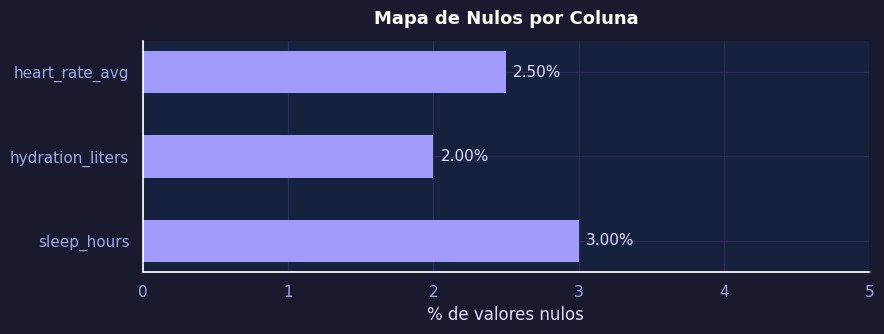

In [14]:
# ── 5.3  Visualização dos nulos ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.barh(resumo_nulos.index, resumo_nulos['Nulos (%)'],
               color=COLORS['accent'], height=0.5, edgecolor='none')
for bar, val in zip(bars, resumo_nulos['Nulos (%)']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', color='#e0e0ff', fontsize=11)
ax.set_xlabel('% de valores nulos')
ax.set_title('Mapa de Nulos por Coluna', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

In [15]:
# ── 5.4  Estratégias de preenchimento ─────────────────────────────────────
df_tratado = df_nulos.copy()

# sleep_hours      → mediana (robusta a outliers)
med_sono = df_tratado['sleep_hours'].median()
df_tratado['sleep_hours'].fillna(med_sono, inplace=True)

# hydration_liters → média global
med_hidrat = df_tratado['hydration_liters'].mean()
df_tratado['hydration_liters'].fillna(round(med_hidrat, 3), inplace=True)

# heart_rate_avg   → média por grupo (calorie_efficiency)
df_tratado['heart_rate_avg'] = df_tratado.groupby(LABEL_COL)['heart_rate_avg'] \
                                          .transform(lambda x: x.fillna(x.mean()))

print(f'✅ Nulos restantes: {df_tratado.isnull().sum().sum()}')
print(f'   sleep_hours      → mediana = {med_sono}')
print(f'   hydration_liters → média   = {med_hidrat:.3f}')
print(f'   heart_rate_avg   → média por grupo ({LABEL_COL})')

✅ Nulos restantes: 50000
   sleep_hours      → mediana = 6.5
   hydration_liters → média   = 2.502
   heart_rate_avg   → média por grupo (calorie_efficiency)


---
## ⚗️ 6. Criação de Novas Colunas (Feature Engineering)

In [16]:
df_feat = df_tratado.copy()

# ── 6.1  Eficiência bruta ─────────────────────────────────────────────────
df_feat['raw_efficiency'] = (
    df_feat['calories_burned'] /
    (df_feat['steps_per_day'] + 20 * df_feat['active_minutes'])
).round(5)

# ── 6.2  Calorias por passo ───────────────────────────────────────────────
df_feat['cal_per_step'] = (df_feat['calories_burned'] / df_feat['steps_per_day']).round(4)

# ── 6.3  Flags de risco ───────────────────────────────────────────────────
df_feat['sono_insuficiente'] = (df_feat['sleep_hours'] < 6).astype(int)
df_feat['overtraining']      = (df_feat['workouts_per_week'] > 6).astype(int)
df_feat['perfil_risco']      = ((df_feat['overtraining'] == 1) &
                                 (df_feat['sono_insuficiente'] == 1)).astype(int)

# ── 6.4  Faixa etária ─────────────────────────────────────────────────────
bins_idade   = [0, 25, 35, 50, 65, 120]
labels_idade = ['18-25', '26-35', '36-50', '51-65', '65+']
df_feat['faixa_etaria'] = pd.cut(df_feat['age'], bins=bins_idade,
                                  labels=labels_idade, right=True)

# ── 6.5  Faixa de IMC (WHO) ───────────────────────────────────────────────
def classificar_bmi(b):
    if b < 18.5:  return 'Abaixo do peso'
    elif b < 25:  return 'Normal'
    elif b < 30:  return 'Sobrepeso'
    else:         return 'Obesidade'

df_feat['faixa_bmi'] = df_feat['bmi'].apply(classificar_bmi)

# ── 6.6  Score de consistência ────────────────────────────────────────────
df_feat['consistency_score'] = (
    df_feat['continuous_exercise_days'] * (df_feat['sleep_hours'] / 8)
).round(3)

# ── 6.7  Zona de FC média ─────────────────────────────────────────────────
def zona_fc(hr):
    if hr < 90:    return 'Repouso'
    elif hr < 114: return 'Leve'
    elif hr < 133: return 'Moderada'
    elif hr < 152: return 'Intensa'
    else:          return 'Máxima'

df_feat['zona_fc_avg'] = df_feat['heart_rate_avg'].apply(zona_fc)

new_cols = ['raw_efficiency','cal_per_step','sono_insuficiente','overtraining',
            'perfil_risco','faixa_etaria','faixa_bmi','consistency_score','zona_fc_avg']
print('✅ Novas colunas criadas:')
df_feat[new_cols].head(6)

✅ Novas colunas criadas:


,raw_efficiency,cal_per_step,sono_insuficiente,overtraining,perfil_risco,faixa_etaria,faixa_bmi,consistency_score,zona_fc_avg
0,0.15255,0.1910,0,0,0,51-65,Normal,0.802,Leve
1,0.23511,0.3112,0,0,0,51-65,Obesidade,2.558,Moderada
2,0.31179,0.3529,0,0,0,51-65,Normal,0.874,Moderada
3,0.19293,0.2390,0,0,0,36-50,Sobrepeso,0.831,Moderada
4,0.18450,0.2311,1,0,0,18-25,Normal,4.350,Moderada
5,0.14427,0.1761,0,0,0,51-65,Sobrepeso,1.605,Leve


---
## 📊 7. Visualizações Exploratórias

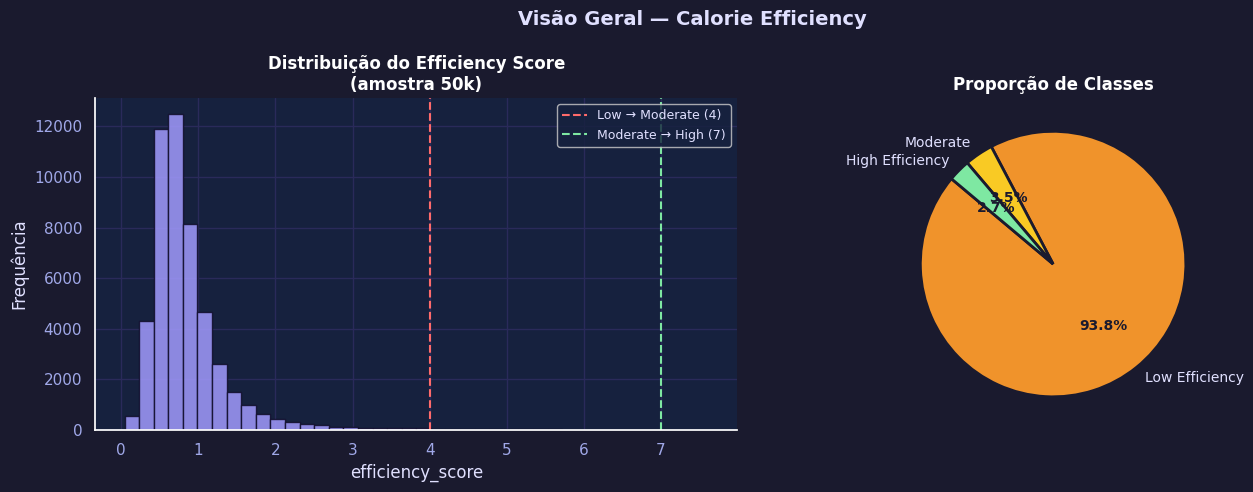

In [17]:
# ── 7.1  Distribuição do Efficiency Score + Pizza de classes ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
amostra = df_feat['efficiency_score'].sample(50_000, random_state=42)
ax.hist(amostra, bins=40, color=COLORS['accent'], edgecolor='#0f0c29', alpha=0.85)
ax.axvline(4, color=COLORS['danger'],           linestyle='--', linewidth=1.5, label='Low → Moderate (4)')
ax.axvline(7, color=COLORS['High Efficiency'],  linestyle='--', linewidth=1.5, label='Moderate → High (7)')
ax.set_title('Distribuição do Efficiency Score\n(amostra 50k)', fontweight='bold')
ax.set_xlabel('efficiency_score')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)

ax = axes[1]
contagens   = df_feat[LABEL_COL].value_counts().reindex(LABELS)
cores_pizza = [COLORS[k] for k in contagens.index]
wedges, texts, autotexts = ax.pie(
    contagens, labels=contagens.index, colors=cores_pizza,
    autopct='%1.1f%%', startangle=140,
    textprops={'color': '#e0e0ff', 'fontsize': 10},
    wedgeprops={'edgecolor': '#1a1a2e', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('#1a1a2e'); at.set_fontweight('bold')
ax.set_title('Proporção de Classes', fontweight='bold')

fig.suptitle('Visão Geral — Calorie Efficiency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

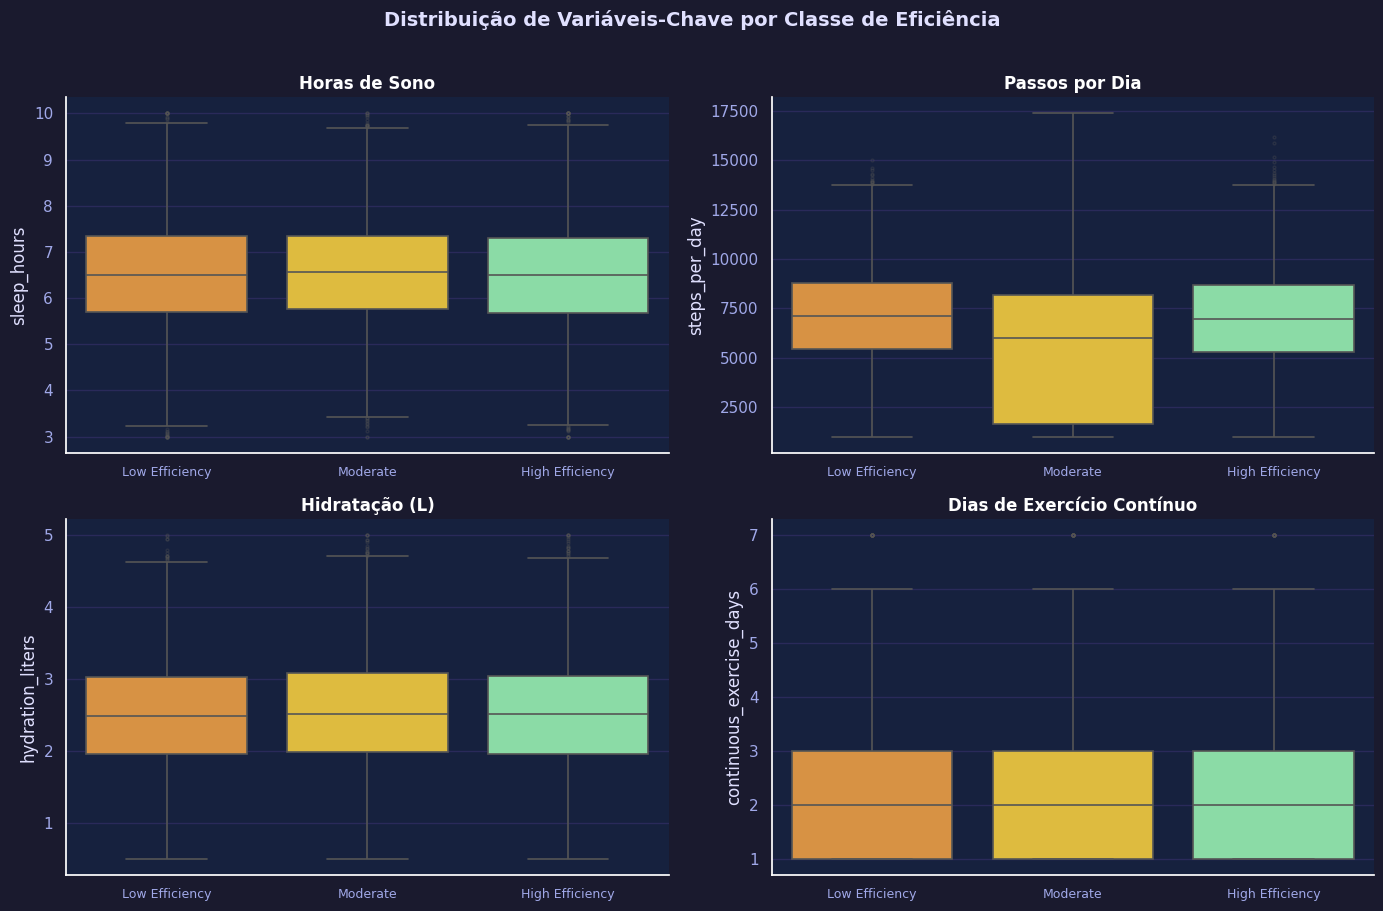

In [18]:
# ── 7.2  Boxplots por classe ───────────────────────────────────────────────
variaveis = ['sleep_hours', 'steps_per_day', 'hydration_liters', 'continuous_exercise_days']
titulos   = ['Horas de Sono', 'Passos por Dia', 'Hidratação (L)', 'Dias de Exercício Contínuo']

amostra_box = (
    df_feat.groupby(LABEL_COL, group_keys=False)[variaveis + [LABEL_COL]]
    .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (var, titulo) in enumerate(zip(variaveis, titulos)):
    ax = axes[i]
    paleta = [COLORS[k] for k in LABELS]
    sns.boxplot(data=amostra_box, x=LABEL_COL, y=var, order=LABELS,
                palette=paleta, ax=ax, linewidth=1.2,
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=9)

fig.suptitle('Distribuição de Variáveis-Chave por Classe de Eficiência',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

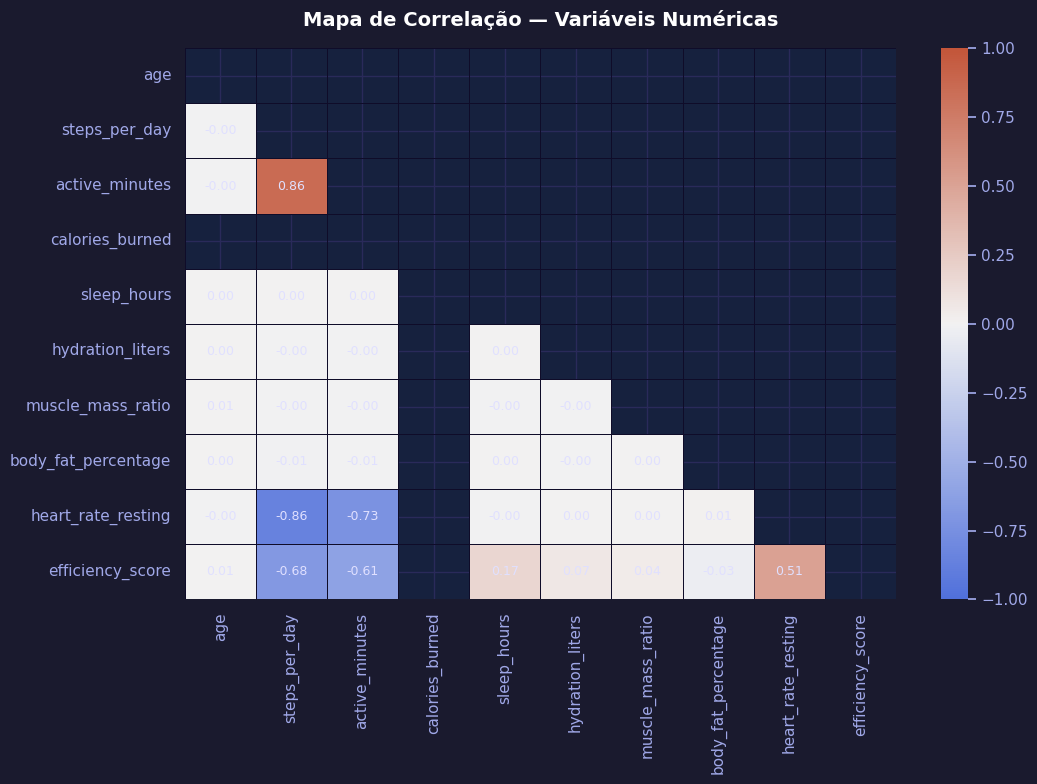

In [19]:
# ── 7.3  Heatmap de correlação ────────────────────────────────────────────
colunas_corr = ['age','steps_per_day','active_minutes','calories_burned','sleep_hours',
                'hydration_liters','muscle_mass_ratio','body_fat_percentage',
                'heart_rate_resting','efficiency_score']

corr = df_feat[colunas_corr].sample(100_000, random_state=42).corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(260, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#0f0c29',
            ax=ax, annot_kws={'size': 9, 'color': '#e0e0ff'})
ax.set_title('Mapa de Correlação — Variáveis Numéricas',
             fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

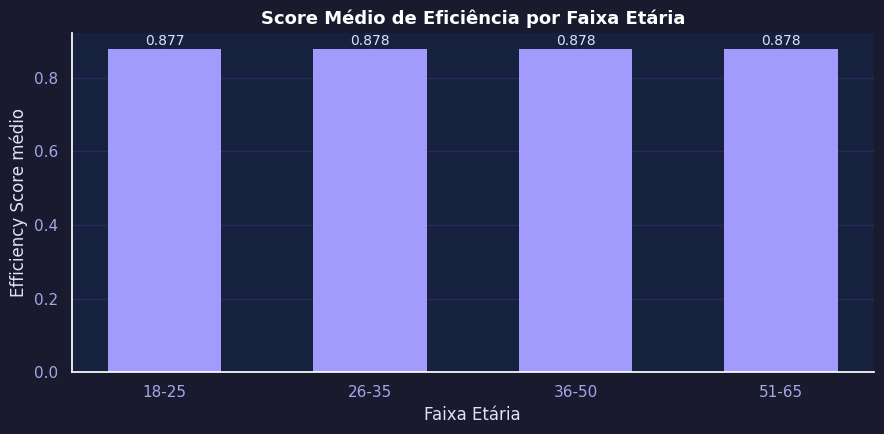

In [20]:
# ── 7.4  Eficiência média por faixa etária ────────────────────────────────
media_por_faixa = (df_feat.groupby('faixa_etaria', observed=True)['efficiency_score']
                           .mean().reset_index())

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(media_por_faixa['faixa_etaria'].astype(str),
              media_por_faixa['efficiency_score'],
              color=COLORS['accent'], edgecolor='none', width=0.55)
for bar, val in zip(bars, media_por_faixa['efficiency_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, color='#e0e0ff')
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Efficiency Score médio')
ax.set_title('Score Médio de Eficiência por Faixa Etária', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

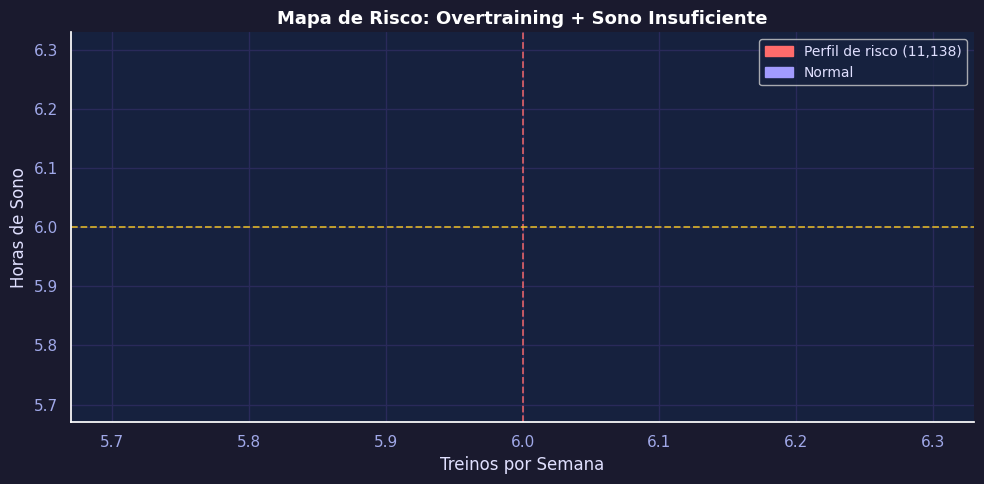

In [21]:
# ── 7.5  Scatter: Overtraining vs Sono ───────────────────────────────────
amostra_sc = df_feat.sample(15_000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    amostra_sc['workouts_per_week'], amostra_sc['sleep_hours'],
    c=[COLORS['danger'] if r else COLORS['accent'] for r in amostra_sc['perfil_risco']],
    alpha=0.35, s=12, edgecolors='none'
)
ax.axvline(6, color=COLORS['danger'],   linestyle='--', linewidth=1.3, alpha=0.8)
ax.axhline(6, color=COLORS['Moderate'], linestyle='--', linewidth=1.3, alpha=0.8)

n_risco = df_feat['perfil_risco'].sum()
patch_r = mpatches.Patch(color=COLORS['danger'], label=f'Perfil de risco ({n_risco:,})')
patch_n = mpatches.Patch(color=COLORS['accent'], label='Normal')
ax.legend(handles=[patch_r, patch_n], fontsize=10)
ax.set_xlabel('Treinos por Semana')
ax.set_ylabel('Horas de Sono')
ax.set_title('Mapa de Risco: Overtraining + Sono Insuficiente', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 💾 8. Salvando o Dataset Tratado

In [22]:
OUTPUT_PATH = 'calorie_efficiency_tratado.csv'
df_feat.to_csv(OUTPUT_PATH, index=False)

print(f'✅ Dataset salvo em: {OUTPUT_PATH}')
print(f'   Shape final       : {df_feat.shape}')
print(f'   Colunas originais : {df.shape[1]}')
print(f'   Novas colunas     : {df_feat.shape[1] - df.shape[1]}')
print(f'   Nulos restantes   : {df_feat.isnull().sum().sum()}')

✅ Dataset salvo em: calorie_efficiency_tratado.csv
   Shape final       : (1000000, 24)
   Colunas originais : 15
   Novas colunas     : 9
   Nulos restantes   : 80000


---
## ✅ 9. Resumo Final

| Etapa | Detalhe |
|---|---|
| **Dataset** | 1.000.000 linhas × 15 colunas · `calorie_efficiency.csv` |
| **Coluna alvo** | `calorie_efficiency`: `Low Efficiency`, `Moderate`, `High Efficiency` |
| **Inspeção** | `head()`, `info()`, `describe()`, distribuição de classes |
| **Seleção** | Coluna única, múltiplas, numéricas vs categóricas |
| **Filtros** | `==`, `&`, `isin()`, `query()`, `between()` |
| **Nulos** | Simulados ~2–3%; tratados com mediana / média / groupby |
| **Features** | 9 novas colunas: faixas etárias, IMC, flags de risco, zonas de FC |
| **Visualizações** | Histograma, pizza, boxplots, heatmap, scatter de risco, barras por idade |
| **Exportação** | `calorie_efficiency_tratado.csv` |